In [10]:
import os
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import drive
import matplotlib.pyplot as plt

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Proiect_Licenta_XAUUSD'

seed_value = 42
np.random.seed(seed_value)
random.seed(seed_value)
tf.random.set_seed(seed_value)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

df = pd.read_csv(f"{PROJECT_PATH}/data/processed/XAUUSD_with_indicators.csv", index_col=0, parse_dates=True)

prediction_horizon = 3
profit_threshold = 0.0005 

df['target_raw'] = np.log(df['close'].shift(-prediction_horizon) / df['close'])
df = df.dropna()

y_class = (df['target_raw'] > profit_threshold).astype(int)

print("Class distribution after applying profit threshold:")
print(y_class.value_counts())

Class distribution after applying profit threshold:
target_raw
0    72557
1    52128
Name: count, dtype: int64


In [5]:

features = [
    'dist_ema_200', 'atr', 'bb_pct', 'fix_vix', 'is_vix_green', 
    'smi_oversold', 'smi_overbought', 'ret_1h', 'ret_3h', 'hour', 'day_of_week'
]
smi_col = [c for c in df.columns if 'smi' in c and 'over' not in c and '_s' not in c][0]
features.append(smi_col)


scaler_x = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_x.fit_transform(df[features])

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 48
X_seq, y_seq = create_sequences(X_scaled, y_class.values, time_steps)

split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]


In [6]:
y_train_flat = y_train.flatten()
class_weights = compute_class_weight(class_weight='balanced', 
                                     classes=np.unique(y_train_flat), 
                                     y=y_train_flat)

class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

print("Calculated Class Weights:")
print(f"Class 0: {class_weights_dict[0]:.4f}")
print(f"Class 1: {class_weights_dict[1]:.4f}")

Calculated Class Weights:
Class 0: 0.8568
Class 1: 1.2008


In [12]:
y_pred_probs = model_lstm_advanced.predict(X_test)

confidence_threshold = 0.54

high_confidence_signals = (y_pred_probs > confidence_threshold).astype(int).flatten()
y_test_flat = y_test.flatten()

trades_taken = np.sum(high_confidence_signals)
winning_trades = np.sum((high_confidence_signals == 1) & (y_test_flat == 1))

if trades_taken > 0:
    actual_win_rate = winning_trades / trades_taken
    print("TRADING PERFORMANCE")
    print(f"Total high-confidence trades executed: {trades_taken}")
    print(f"Winning trades: {winning_trades}")
    print(f"Actual Win Rate: {actual_win_rate:.2%}")
else:
    print("Confidence threshold is too high. The model found 0 safe trades.")

779/779 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step
TRADING PERFORMANCE
Total high-confidence trades executed: 299
Winning trades: 161
Actual Win Rate: 53.85%


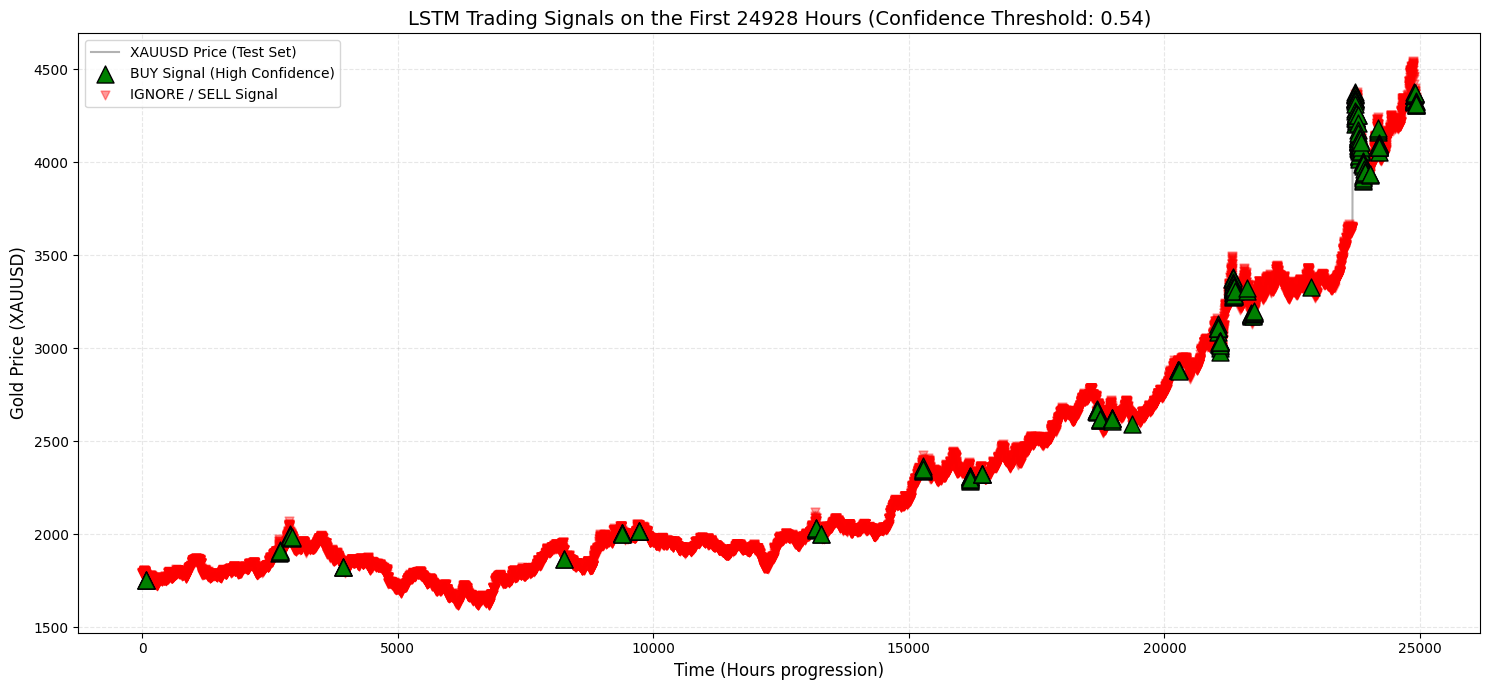

In [11]:
y_pred_classes = (y_pred_probs > confidence_threshold).astype(int).flatten()

test_prices = df['close'].iloc[split + time_steps:].values

view_window = len(test_prices)

plt.figure(figsize=(15, 7))

plt.plot(test_prices[:view_window], label='XAUUSD Price (Test Set)', color='gray', alpha=0.6, linewidth=1.5)

buy_signals = np.where(y_pred_classes[:view_window] == 1)[0]
plt.scatter(buy_signals, test_prices[buy_signals], 
            marker='^', color='green', label='BUY Signal (High Confidence)', 
            s=150, zorder=5, edgecolors='black')

sell_signals = np.where(y_pred_classes[:view_window] == 0)[0]
plt.scatter(sell_signals, test_prices[sell_signals], 
            marker='v', color='red', label='IGNORE / SELL Signal', 
            s=40, alpha=0.4, zorder=4)

plt.title(f'LSTM Trading Signals on the First {view_window} Hours (Confidence Threshold: {confidence_threshold})', fontsize=14)
plt.xlabel('Time (Hours progression)', fontsize=12)
plt.ylabel('Gold Price (XAUUSD)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()